### Read in NYISO Parquests

In [ ]:
# Read and aggregate all 2023 parquet files into memory
import os, glob
import pandas as pd
import numpy as np

# SOURCE_DIR already defined in an earlier cell; redefine here for safety if needed
from pathlib import Path

SOURCE_DIR = Path("1_LIB/nyiso/nyiso_parquet/2023")
SOURCE_DIR

def find_parquets(src):
    pattern = os.path.join(src, '**', '*.parquet')
    return sorted(glob.glob(pattern, recursive=True))

def load_parquets(paths):
    dfs = []
    for p in paths:
        try:
            df = pd.read_parquet(p)
            df['_source_file'] = os.path.basename(p)
            dfs.append(df)
        except Exception as e:
            print(f"Warning: failed to read {p}: {e}")
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)

def ensure_datetime(df, col='Time Stamp'):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    else:
        for alt in ['Timestamp','timestamp','time','datetime','time_stamp']:
            if alt in df.columns:
                df.rename(columns={alt: col}, inplace=True)
                df[col] = pd.to_datetime(df[col], errors='coerce')
                break
    return df

# --- Load files into memory ---
paths = find_parquets(SOURCE_DIR)
print(f"Found {len(paths)} parquet files under {SOURCE_DIR}")

df_all = load_parquets(paths)
print(f"Loaded total rows: {len(df_all)}")

# Keep dataframe in memory as `df_all` and build aggregates
if df_all.empty:
    print('No data loaded from parquet files')
else:
    df_all = ensure_datetime(df_all)
    # basic summary
    print('Columns:', df_all.columns.tolist())
    if 'Load' in df_all.columns:
        print(df_all['Load'].describe())
    # Create time-based aggregates in-memory
    if 'Time Stamp' in df_all.columns and 'Load' in df_all.columns:
        df_all.set_index('Time Stamp', inplace=True)
        # 5-minute and 15-minute aggregates
        five = df_all['Load'].resample('5T').sum().to_frame('total_load')
        quarter = df_all['Load'].resample('15T').sum().to_frame('total_load')
        hourly = df_all['Load'].resample('H').sum().to_frame('total_load')
        daily = df_all['Load'].resample('D').sum().to_frame('total_load')
        per_name_daily = df_all.groupby([pd.Grouper(freq='D'), 'Name'])['Load'].sum().unstack(fill_value=0)
        print('Aggregates created in memory: `five`, `quarter`, `hourly`, `daily`, per-name tables')
    else:
        print('Missing Time Stamp or Load column; cannot create aggregates')
        
        # per-name aggregates at those frequencies (wide form)
        # per_name_5min = df_all.groupby([pd.Grouper(freq='5T'), 'Name'])['Load'].sum().unstack(fill_value=0)
        # per_name_15min = df_all.groupby([pd.Grouper(freq='15T'), 'Name'])['Load'].sum().unstack(fill_value=0)




Found 365 parquet files under C:\Users\Matt\Desktop\CS506\CS506_Project\1_LIB\nyiso\nyiso_parquet\2023
Loaded total rows: 1180025
Columns: ['Time Stamp', 'Time Zone', 'Name', 'PTID', 'Load', '_source_file']
count    1.179992e+06
mean     1.527415e+03
std      1.429003e+03
min      1.265235e+02
25%      6.872794e+02
50%      1.093257e+03
75%      1.695525e+03
max      1.042956e+04
Name: Load, dtype: float64


C:\Users\Matt\AppData\Local\Temp\ipykernel_15624\417501445.py:57: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  five = df_all['Load'].resample('5T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_15624\417501445.py:58: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  quarter = df_all['Load'].resample('15T').sum().to_frame('total_load')
C:\Users\Matt\AppData\Local\Temp\ipykernel_15624\417501445.py:59: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df_all['Load'].resample('H').sum().to_frame('total_load')


Aggregates created in memory: `five`, `quarter`, `hourly`, `daily`, per-name tables


In [ ]:
#DELETE VARS FROM MEMORY 

del daily, df_all, five, hourly, paths, per_name_daily, SOURCE_DIR


### Graph

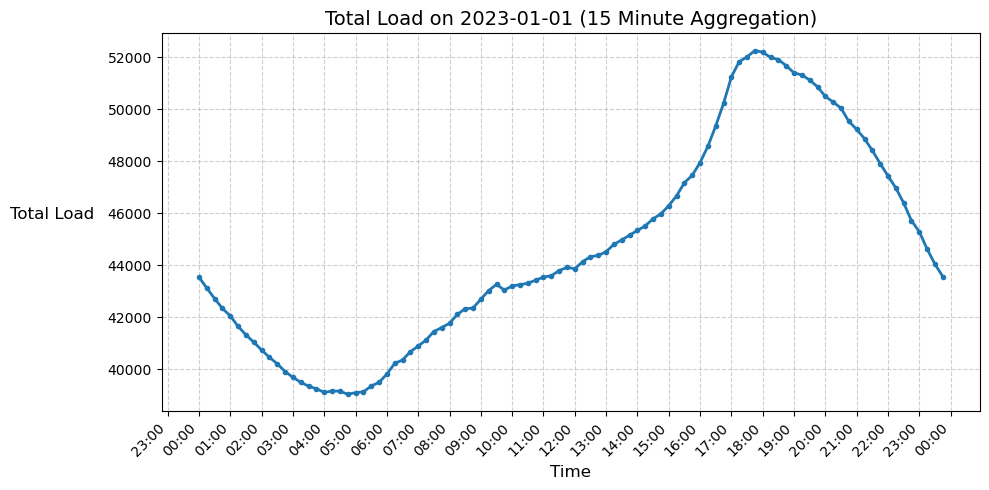

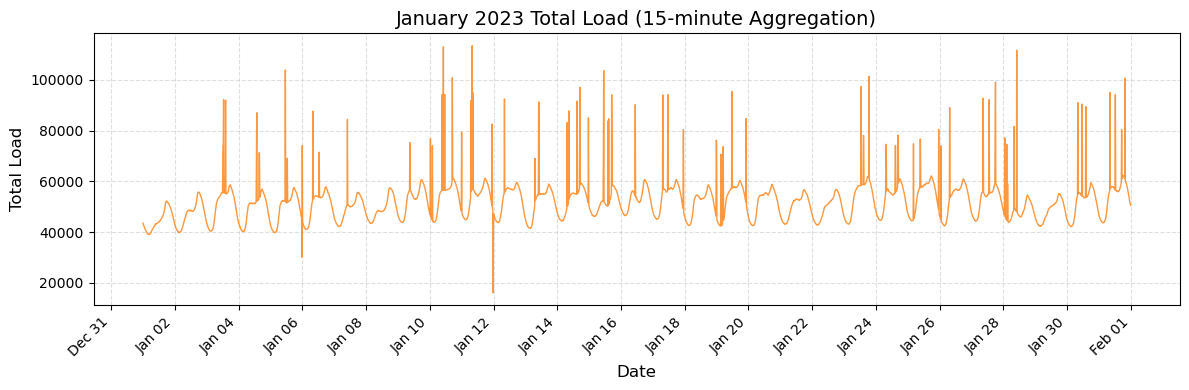

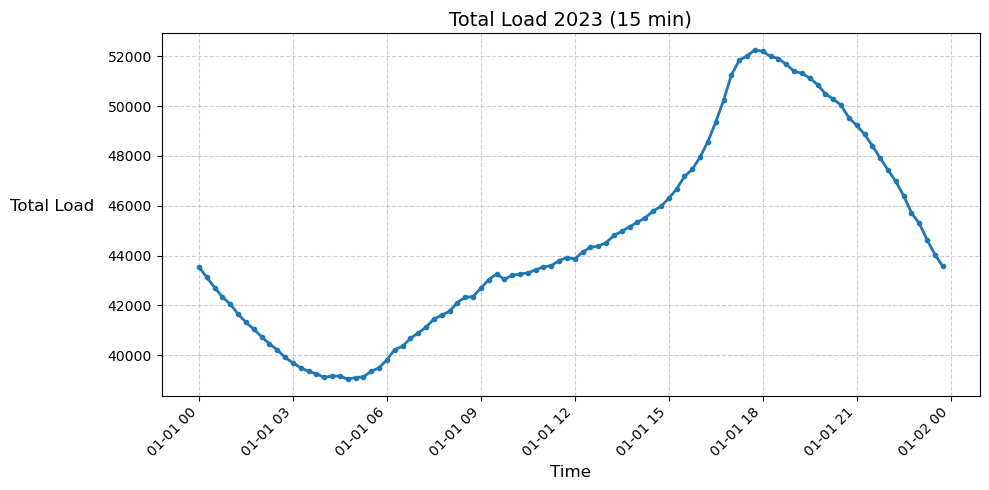

In [ ]:
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt
import pandas as pd


#PLOTS

x = quarter.datetime
y = quarter.total_load


    # TODO: DAILY
# Filter for one day (first day in dataset)
one_day = quarter[quarter['datetime'].dt.date == quarter['datetime'].dt.date.iloc[0]]

# --- PLOT ---
plt.figure(figsize=(10, 5))
plt.plot(one_day['datetime'], one_day['total_load'],
         color='tab:blue', linewidth=2, marker='.', markersize=6)

# --- LABELS AND TITLE ---
plt.title(f'Total Load on {one_day["datetime"].dt.date.iloc[0]} (15 Minute Aggregation)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))

plt.ylabel('Total Load', fontsize=12, rotation= 360, labelpad = 40)  # proper y-axis rotation

# --- ROTATE X-TICK LABELS ---
plt.xticks(rotation=45, ha='right')  # rotate labels and align right

# --- GRID ---
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust spacing so nothing intersects
plt.tight_layout()

plt.show()

#     # TODO: MONTHLY 


import matplotlib.dates as mdates

jan = quarter[quarter['datetime'].dt.month == 1].copy()
plt.figure(figsize=(12, 4))
plt.plot(jan['datetime'], jan['total_load'], color='tab:orange', linewidth=1, alpha=0.8)
plt.title('January 2023 Total Load (15-minute Aggregation)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Load', fontsize=12)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

#     # TODO: YEARLY 


plt.figure(figsize=(10, 5))
plt.plot(one_day['datetime'], one_day['total_load'],
         color='tab:blue', linewidth=2, marker='.', markersize=6)

# --- LABELS AND TITLE ---
plt.title('Total Load 2023 (15 min)', fontsize=14)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Total Load', fontsize=12, rotation= 360, labelpad = 40)  # proper y-axis rotation
plt.xticks(rotation=45, ha='right')  # rotate labels and align right
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


#### Spline

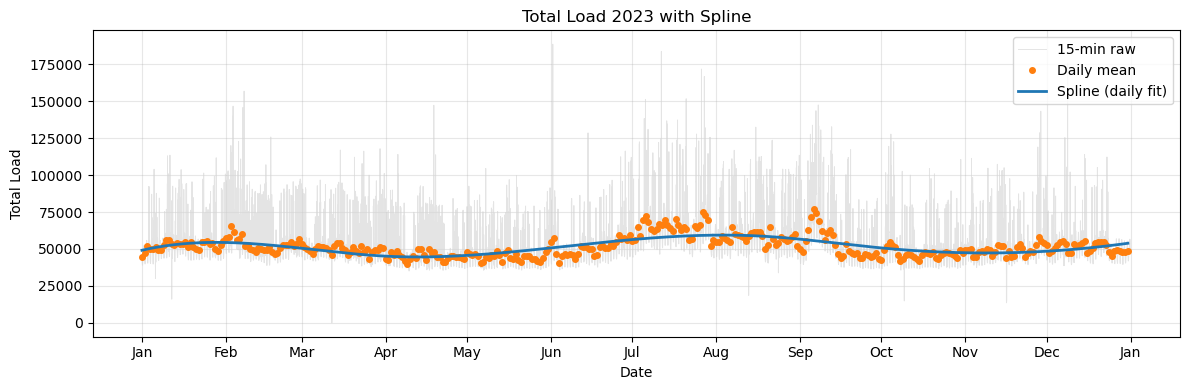

In [64]:
from scipy.interpolate import UnivariateSpline


# Aggregate to daily means for a stable spline fit
daily = quarter.set_index('datetime')['total_load'].resample('D').mean().reset_index()

# Convert dates to numeric values for spline fitting
x_num = mdates.date2num(daily['datetime'])
y_daily = daily['total_load'].values

# Fit a smoothing spline (adjust `s` to change smoothness)
s = len(x_num) * np.var(y_daily) * 0.5
spline = UnivariateSpline(x_num, y_daily, s=s)

# Evaluate spline on a dense grid for a smooth curve
x_dense = np.linspace(x_num.min(), x_num.max(), 1000)
y_smooth = spline(x_dense)
x_dense_dates = mdates.num2date(x_dense)

# Plot original 15-min data (light), daily means (points), and spline (smooth)
plt.figure(figsize=(12, 4))
plt.plot(quarter['datetime'], quarter['total_load'], color='lightgray', linewidth=0.7, alpha=0.6, label='15-min raw')
plt.plot(daily['datetime'], daily['total_load'], 'o', color='tab:orange', markersize=4, label='Daily mean')
plt.plot(x_dense_dates, y_smooth, color='tab:blue', linewidth=2, label='Spline (daily fit)')
plt.title('Total Load 2023 with Spline')
plt.xlabel('Date')
plt.ylabel('Total Load')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()







### Summary Statistics

In [ ]:
#TODO: Create Summary Statistics for Hourly, Month, Year 

periods = {'Jan 1': one_day, 'January': jan, 'Year': quarter}
rows = []
for name, df in periods.items():
    if df.empty:
        rows.append({'period': name, 'count': 0})
        continue
    s = df['total_load'].describe()
    peak_idx = df['total_load'].idxmax()
    peak_time = df.loc[peak_idx, 'datetime']
    peak_val = df.loc[peak_idx, 'total_load']
    rows.append({
        'period': name,
        'count': int(s['count']),
        'mean': round(s['mean'], 2),
        'std': round(s['std'], 2),
        'min': round(s['min'], 2),
        '25%': round(s['25%'], 2),
        '50%': round(s['50%'], 2),
        '75%': round(s['75%'], 2),
        'max': round(s['max'], 2),
        'sum': round(df['total_load'].sum(), 2),
        'peak_time': pd.to_datetime(peak_time).strftime('%Y-%m-%d %H:%M:%S'),
        'peak_value': round(peak_val, 2),
    })

summary_stats = pd.DataFrame(rows).set_index('period')
summary_stats


,count,mean,std,min,25%,50%,75%,max,sum,peak_time,peak_value
period,,,,,,,,,,,
Jan 1,96,44649.26,4030.55,39038.18,41418.57,43830.98,47573.51,52258.58,4.286329e+06,2023-01-01 17:45:00,52258.58
January,2976,52105.00,8119.54,16029.43,46389.18,52288.37,55976.00,113504.77,1.550645e+08,2023-01-11 08:00:00,113504.77
Year,35040,51436.57,11105.31,0.00,44526.42,49341.50,55487.42,188607.07,1.802337e+09,2023-06-01 16:00:00,188607.07
